**- - - - -  20/04/2026--------------Scikit-learn's ColumnTransformer-------**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer  # for filling the missing value
from sklearn.preprocessing import LabelEncoder,OneHotEncoder ## Encodeing
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer



In [ ]:
df=pd.read_csv('/content/covid_toy - covid_toy.csv')
df.head(5)

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
fever,10
cough,0
city,0
has_covid,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['has_covid']),df['has_covid'],test_size=0.2)


In [ ]:
X_train

,age,gender,fever,cough,city
3,31,Female,98.0,Mild,Kolkata
71,75,Female,104.0,Strong,Delhi
63,10,Male,100.0,Mild,Bangalore
99,10,Female,98.0,Strong,Kolkata
25,23,Male,NaN,Mild,Mumbai
...,...,...,...,...,...
32,34,Female,101.0,Strong,Delhi
33,26,Female,98.0,Mild,Kolkata
48,66,Male,99.0,Strong,Bangalore
84,69,Female,98.0,Strong,Mumbai


**Manually type output**

In [ ]:
#add simple imputer to fever column
si=SimpleImputer(strategy='mean')
X_train_fever=si.fit_transform(X_train[['fever']])
# also the test data
X_test_fever=si.fit_transform(X_test[['fever']])
X_train_fever.shape

(80, 1)

In [ ]:
#ordinal Encoding -->cough
oe=OrdinalEncoder(categories=[['Mild','Strong']])
X_train_cough=oe.fit_transform(X_train[['cough']])
# also the test data
X_test_cough=oe.fit_transform(X_test[['cough']])

X_train_cough.shape

(80, 1)

In [ ]:
#onehotEncoding -->Gender,city
ohe=OneHotEncoder(drop='first',sparse_output=False)
X_train_gender_city=ohe.fit_transform(X_train[['gender','city']])
#also the test data
X_test_gender_city=ohe.fit_transform(X_test[['gender','city']])
X_train_gender_city.shape

X_train_gender_city.shape

(80, 4)

In [ ]:
#Extracting Age
X_train_age=X_train.drop(columns=['gender','fever','cough','city']).values
#also the test data
X_test_age=X_test.drop(columns=['gender','fever','cough','city']).values
X_train_age.shape


(80, 1)

In [ ]:
x_train_transformed=np.concatenate((X_train_age,
                                    X_train_fever,X_train_gender_city,
                                    X_train_cough),axis=1)

In [ ]:
# x_test_transformed=np.concatenate((X_test_age,
#                                     X_test_fever,X_test_gender_city,
#                                     X_test_cough),axis=1)

In [ ]:
x_train_transformed.shape


(80, 7)

**by the help of column transformer**

In [ ]:
transformer=ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    #help of SI we
    #fill missing value by mean,median,mode.
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    #this process
    #we encoder our data
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['gender','city'])],remainder='passthrough')
     # remainder= passthrough ==> it means rest all the col8mn remain same.

In [ ]:
transformer.fit_transform(X_train).shape

(80, 7)

practices

In [ ]:
df=pd.read_csv('/content/insurance - insurance.csv')
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['charges']),df['charges'],test_size=0.2)

In [ ]:
x_train.head(5)

,age,sex,bmi,children,smoker,region
940,18,male,23.21,0,no,southeast
973,19,female,40.50,0,no,southwest
1233,58,male,23.30,0,no,southwest
109,63,male,35.09,0,yes,southeast
229,47,male,25.46,2,no,northeast


In [ ]:
si=SimpleImputer(strategy='mean')
x_train_bmi=si.fit_transform(x_train[['bmi']])
x_test_bmi=si.fit_transform(x_test[['bmi']])
x_train_bmi.shape

(1070, 1)

In [ ]:
ohe=OneHotEncoder(drop='first',sparse_output=False)
x_train_smoker=ohe.fit_transform(x_train[['smoker']])
x_test_smoker=ohe.fit_transform(x_test[['smoker']])
x_train_smoker.shape

(1070, 1)

In [ ]:
ohe=OneHotEncoder(drop='first',sparse_output=False)
x_train_sex=ohe.fit_transform(x_train[['sex']])
x_test_sex=ohe.fit_transform(x_test[['sex']])
x_train_sex.shape

(1070, 1)

In [ ]:
oe=OrdinalEncoder(categories=[['southwest','southeast','northwest','northeast']])
x_train_region=oe.fit_transform(x_train[['region']])
x_test_region=oe.fit_transform(x_test[['region']])
x_train_region.shape

(1070, 1)

In [ ]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
si=SimpleImputer(strategy='mean')
x_train_children=si.fit_transform(x_train[['children']])
x_test_children=si.fit_transform(x_test[['children']])
x_train_children.shape

(1070, 1)

In [ ]:
x_train_transformed=np.concatenate((x_train_bmi,x_train_smoker,x_train_sex,x_train_region,x_train_children),axis=1)

In [ ]:
x_train_transformed.shape

(1070, 5)

In [ ]:
transformer=ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['bmi']),
    ('tnf2',OrdinalEncoder(categories=[['southwest','southeast','northwest','northeast']]),['region']),
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['smoker','sex']),
    ('tnf4',SimpleImputer(),['children'])],remainder='passthrough')


In [ ]:
transformer.fit_transform(x_train).shape

(1070, 6)

- - - **23/04/2026 ---------------Remove Outliers**----------------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/newplacementdata - newplacementdata.csv')
df.head(5)

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


In [3]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

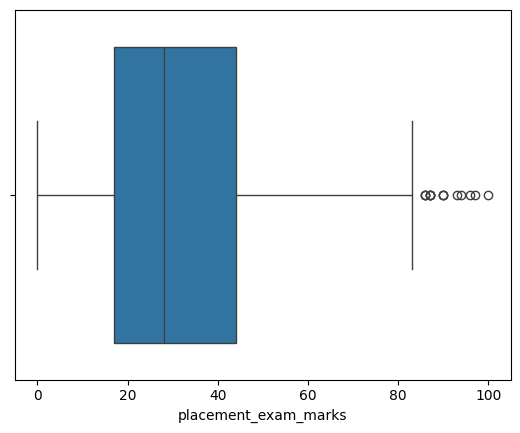

In [4]:
sns.boxplot(x=df['placement_exam_marks'])

In [5]:
#finding the IQR
Q1=df['placement_exam_marks'].quantile(0.25)
Q3=df['placement_exam_marks'].quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,)

17.0 44.0


In [6]:
IQR=Q3-Q1
print("IQR:", IQR)

IQR: 27.0


In [7]:
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR
print("upper limit:",upper_limit)
print("lower limit:",lower_limit)


upper limit: 84.5
lower limit: -23.5


**Finding our Outliers**

In [8]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94,1
40,6.60,86,1
61,7.51,86,0
134,6.33,93,0
162,7.80,90,0
283,7.09,87,0
290,8.38,87,0
311,6.97,87,1
324,6.64,90,0
630,6.56,96,1


In [9]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [10]:
#trmming (outlier removing technique 1)
newdf=df[df['placement_exam_marks']<upper_limit]


In [11]:
newdf.head()

,cgpa,placement_exam_marks,placed
0,7.19,26,1
1,7.46,38,1
2,7.54,40,1
3,6.42,8,1
4,7.23,17,0


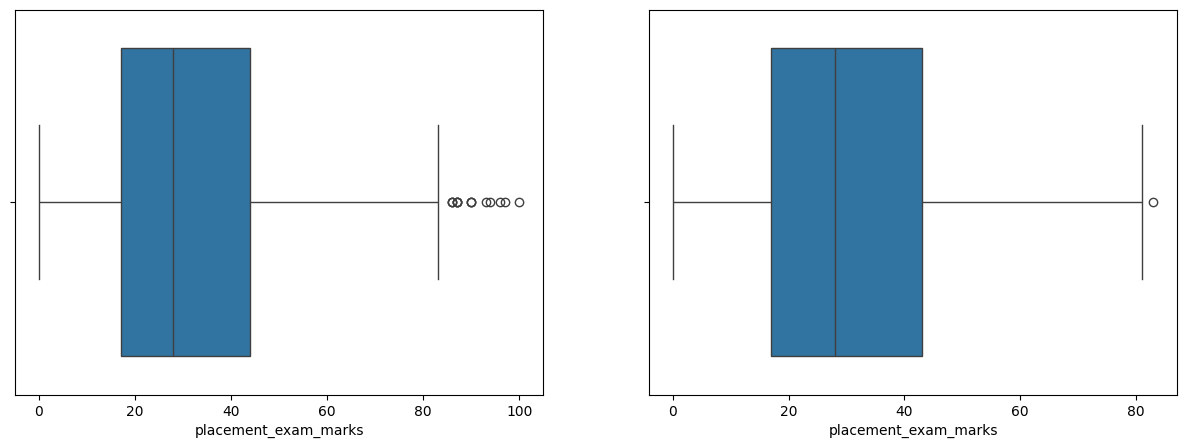

In [13]:
#comparsion
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['placement_exam_marks'])
plt.subplot(1,2,2)
sns.boxplot(x=newdf['placement_exam_marks'])

plt.show()

In [14]:
#cpping(outlier removing technique 2)
new_df_cap=df.copy()
new_df_cap['placement_exam_marks']=np.where(new_df_cap['placement_exam_marks']>upper_limit,upper_limit,
                                             np.where(new_df_cap['placement_exam_marks']<lower_limit,lower_limit,
                                                      new_df_cap['placement_exam_marks']))


In [15]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [16]:
new_df=df[df['placement_exam_marks']<upper_limit]

paractice:-


In [ ]:
df=pd.read_csv('/content/titanic - titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df['Age'].describe()

,Age
count,332.000000
mean,30.272590
std,14.181209
min,0.170000
25%,21.000000
50%,27.000000
75%,39.000000
max,76.000000


In [ ]:
df['Age'].isnull().sum()

np.int64(86)

<Axes: xlabel='Age'>

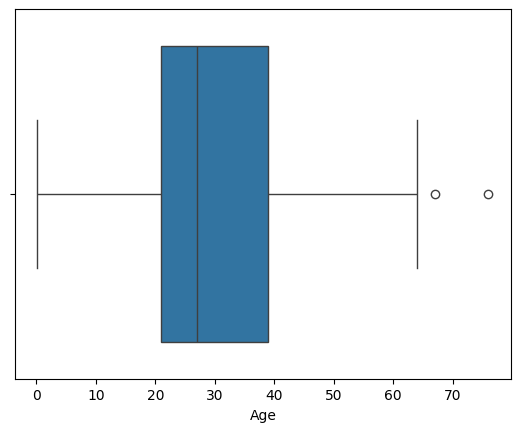

In [ ]:
sns.boxplot(x=df['Age'])

In [ ]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,)
print("IQR",IQR)

21.0 39.0
IQR 18.0


In [ ]:
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR
print("upper limit:",upper_limit)
print("lower limit:",lower_limit)

upper limit: 66.0
lower limit: -6.0


In [ ]:
df[df['Age']>upper_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
81,973,0,1,"Straus, Mr. Isidor",male,67.0,1,0,PC 17483,221.7792,C55 C57,S
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S


In [ ]:
df[df['Age']<lower_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [ ]:
newdf=df[df['Age']<upper_limit]

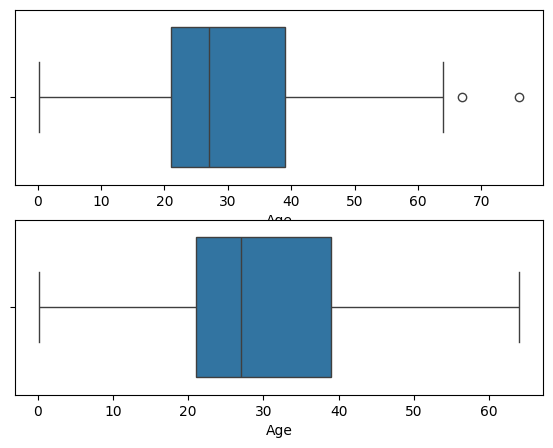

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(222)
sns.boxplot(x=df['Age'])
plt.subplot(224)
sns.boxplot(x=newdf['Age'])
plt.show()
